In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tools.sm_exceptions import ValueWarning
import tqdm
import datetime

tickers = ['NVDA', 'GOOGL', 'AAPL', 'GOOG', 'MSFT', 'AMZN', 'TSM', 'AVGO', 'META', 'TSLA', 'SMCI']

forex_tickers = [
    "EURUSD=X",
    "GBPUSD=X",
    "USDJPY=X",
    "USDCHF=X",
    "AUDUSD=X",
    "USDCAD=X",
    "NZDUSD=X",
    "EURGBP=X",
    "EURJPY=X",
    "GBPJPY=X",
    "EURCHF=X"
]

# for log and output save
now = datetime.datetime.now()
date = now.strftime("%Y-%m-%d %H:%M:%S")

In [ ]:
def load_stock(start_date, stock='NVDA'):
    df = yf.download(stock, start=start_date, end='2026-01-01', interval='1d')

    if isinstance(df.columns, pd.MultiIndex):
        lvl0 = df.columns.get_level_values(0)
        lvl1 = df.columns.get_level_values(1)

        if 'Close' in lvl0:
            df.columns = lvl0
        elif 'Close' in lvl1:
            df.columns = lvl1

    df = df.loc[:, ~df.columns.duplicated()].copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df.dropna(subset=['Close']).copy()
        
    return df

[*********************100%***********************]  1 of 1 completed


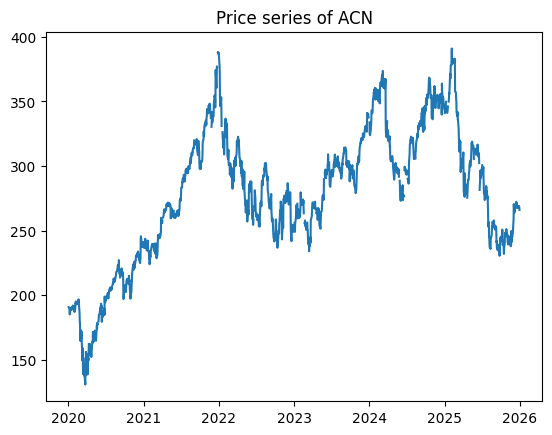

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,190.896164,192.504001,189.678937,191.541120,2431100.0
2020-01-03,190.578232,191.332189,188.034764,189.397334,1802100.0
2020-01-06,189.333725,189.660742,187.862153,189.188395,2841400.0
2020-01-07,185.246002,187.362530,184.573810,184.582888,3097400.0
2020-01-08,185.609375,186.626757,184.882668,185.309608,2271300.0


In [4]:
# here i will import the data for creating the time series
stock = 'ACN'
data = load_stock(start_date='2020-01-01', stock=stock)

plt.plot(data['Close'])
plt.title(f'Price series of {stock}')
plt.show()

data.head()

In [ ]:
# ARIMA prediction function

def get_arima_feature(data, input=(4,0,1), window=252):
    df = data.copy()

    df['arima_pred'] = np.nan
    y = df['ret_1']

    for i in range(1, len(df)):
        start_idx = max(0, i - window)
        history = y.iloc[start_idx:i].dropna()

        if len(history) < 10:
            continue

        try:
            # turn down warnings
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", ConvergenceWarning)
                warnings.simplefilter("ignore", ValueWarning)
                warnings.simplefilter("ignore", FutureWarning)

                model = ARIMA(history, order=input)
                fit = model.fit()
                pred = fit.forecast(steps=1).iloc[0]
                
            df.iloc[i, df.columns.get_loc('arima_pred')] = pred

        except Exception:
            continue

    df['arima_sgn'] = np.sign(df['arima_pred']).fillna(0).astype(int)
    df['arima_intensity'] = df['arima_pred'].abs()

    return df

In [ ]:
# new feature selected by correlation

def build_feature(data, nxxs=3, nxs=5, ns=10, nm=20, nb=50, dropna=True):

    data = data.copy()

    ### returns ###
    data['ret_1'] = data['Close'].pct_change(1) # (data['Close]-data['Close].shift(1))/data['Close].shift(1) -1
    data['ret_5'] = data['Close'].pct_change(5)
    data['ret_10'] = data['Close'].pct_change(10)
    
    ### moving averages ###
    data[f'MA{ns}'] = data['Close'].rolling(ns).mean()
    data[f'MA{nm}'] = data['Close'].rolling(nm).mean()
    data[f'MA{nb}'] = data['Close'].rolling(nb).mean()

    ### distance from moving average ###
    # better to calculate the distance (NORMALIZED) from the MA
    data[f'MA{ns}dis'] = (data['Close']/data[f'MA{ns}'])-1
    data[f'MA{nm}dis'] = (data['Close']/data[f'MA{nm}'])-1
    data[f'MA{nb}dis'] = (data['Close']/data[f'MA{nb}'])-1

    ### exponential moving avg ###
    def multiplier(n):
        return 2 / (n + 1)

    def ema(data, n):
        col = f'EMA{n}'
        alpha = multiplier(n)

        data[col] = np.nan
        data.loc[data.index[0], col] = data['Close'].iloc[0]

        for i in range(1, len(data)):
            data.loc[data.index[i], col] = (
                alpha * data['Close'].iloc[i]
                + (1 - alpha) * data.loc[data.index[i - 1], col]
            )

        return data

    data = ema(data,ns)
    data = ema(data,nm)
    data = ema(data,nb)

    ### distance from EMA ###
    data[f'EMA{ns}dis'] = data['Close']/data[f'EMA{ns}'] - 1
    data[f'EMA{nm}dis'] = data['Close']/data[f'EMA{nm}'] - 1
    data[f'EMA{nb}dis'] = data['Close']/data[f'EMA{nb}'] - 1

    ### z-score ###
    data[f'z{nxxs}'] = (data['Close']-data['Close'].rolling(nxxs).mean())/data['Close'].rolling(nxxs).std()
    data[f'z{nxs}'] = (data['Close']-data['Close'].rolling(nxs).mean())/data['Close'].rolling(nxs).std()
    data[f'z{ns}'] = (data['Close']-data['Close'].rolling(ns).mean())/data['Close'].rolling(ns).std()

    ### volatility ###
    data[f'vol{nxs}'] = data['ret_1'].rolling(nxs).std()
    data[f'vol{ns}'] = data['ret_1'].rolling(ns).std()
    data[f'vol{nm}'] = data['ret_1'].rolling(nm).std()

    ### bollinger bands ###
    # 2std aroud the moving avg, better to calculate the distance from the boundaries
    data[f'bb_upper_{nm}_dis'] = data['Close']/(data[f'MA{nm}'] + 2*data[f'vol{nm}']) - 1
    data[f'bb_lower_{nm}_dis'] = data['Close']/(data[f'MA{nm}'] - 2*data[f'vol{nm}']) - 1

    ### momentum ###
    data[f'momentum{ns}'] = data['Close'] - data['Close'].shift(ns)
    data[f'momentum{nm}'] = data['Close'] - data['Close'].shift(nm)

    ### ARIMA sgn and intensity ###
    data = get_arima_feature(data)

    ### tagrte ###
    data['target'] = (data['ret_1'].shift(-1) > 0).astype(int)

    ### feature list ###
    features = ['bb_lower_20_dis','MA20dis','MA50dis', 'z5' , 'EMA20dis','EMA50dis','MA10dis','EMA10dis','z3','ret_1', 'arima_sgn', 'arima_intensity']

    if dropna:
        data = data.dropna()

    return data, features


In [13]:
# define train and test split

# train_size = round(len(data) * 0.7)

split_date = '2024-06-30'

data, features = build_feature(data)

train = data.loc[data.index < split_date]
test = data.loc[data.index > split_date]

train = train.copy()
test = test.copy()

KeyboardInterrupt: 

In [ ]:
# creation of prediction column + THRESHOLD TESTING

# model selected: 
n_estimators= 100
max_depth= 5
learning_rate= 0.15
subsample= 0.7
colsample_bytree= 0.7

# threshold = 0.6

df = pd.DataFrame()

model = XGBClassifier(
    n_estimators=n_estimators,
    max_depth=max_depth,
    learning_rate=learning_rate,
    subsample=subsample,
    colsample_bytree=colsample_bytree,
    random_state=42
)

model.fit(train[features],train['target'])

test['prediction'] = model.predict(test[features])
test['prediction_prob'] = model.predict_proba(test[features])[:,1]

# evaluate model

test['signal'] = 0 # inside the threshold i dont want to trade

for threshold in [0.5,0.52,0.54,0.56,0.58,0.6,0.62,0.64,0.66,0.68,0.7]:

    sig = np.zeros(len(test))

    sig[test['prediction_prob'] > threshold] = 1
    sig[test['prediction_prob'] < (1 - threshold)] = -1

    test[f'signal_{threshold}'] = sig

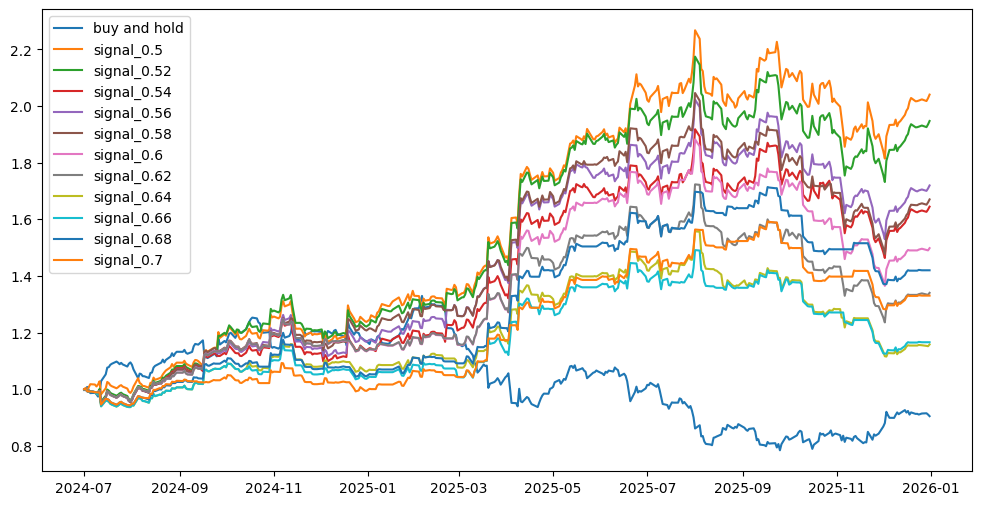

buy and hold 0.904507156705463
signal_0.5 2.040316728658626
signal_0.52 1.9471778291728246
signal_0.54 1.644579033722153
signal_0.56 1.719458270063333
signal_0.58 1.6701579723357398
signal_0.6 1.4979908840832166
signal_0.62 1.3400426959464489
signal_0.64 1.1577029282828093
signal_0.66 1.1656238395894567
signal_0.68 1.4197688175020986
signal_0.7 1.3302756904922661


In [66]:
# trade strategy --> ALL EQUAL ENTRY

signal_cols = [col for col in test.columns if col.startswith('signal_')]
# adding costs
cost = 0.001 # per transaction
test['buy_and_hold'] = (1 + test['ret_1']).cumprod()

for col in signal_cols:

    # position need to be shifted
    test['position'] = test[col].shift(1)

    # same as above
    # test['future_ret'] = test['ret_1'].shift(-1)
    # test['strategy_ret'] = test['prediction'] * test['future_ret']

    # when the position is 1 I'm following the prediction and so I'm LONG in, viceversa if position is -1 (the next day prediction is 0 so red candle)
    test['strategy_return'] = test['position'] * test['ret_1']
    test['strategy_return'] = test['strategy_return'].fillna(0) # first rows will be NaN because of the shifts

    # EQUITY
    test[f'equity_{col}'] = (1 + test['strategy_return']).cumprod()

    test['trade'] = test['position'].diff().abs().fillna(0)

    test['strategy_ret_net'] = test['strategy_return'] - cost * test['trade']# * test['equity'] depend if i change my trading size according to my present equit or if it is fixed
    test[f'equity_net_{col}'] = (1 + test['strategy_ret_net'].fillna(0)).cumprod()

# plot results

plt.figure(figsize=(12,6))
plt.plot(test['buy_and_hold'],label='buy and hold')
# plt.plot(test['equity'],label='strategy')
for col in signal_cols:
    plt.plot(test[f'equity_net_{col}'],label=col)
plt.legend()
plt.show()

print('buy and hold', test['buy_and_hold'].iloc[-1])
for col in signal_cols:
    print(col, test[f'equity_net_{col}'].iloc[-1])

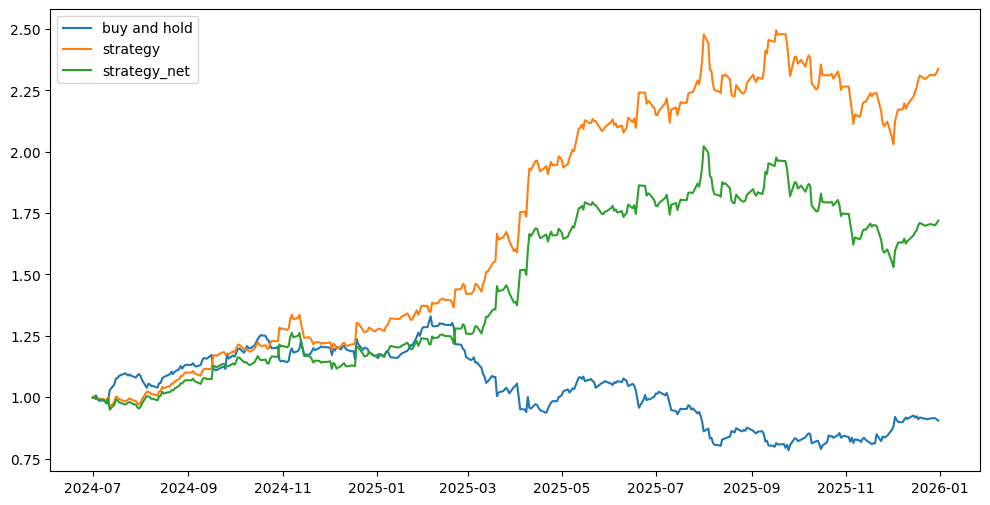

buy and hold 0.904507156705463
top threshold (net) 1.719458270063333
top threshold 2.3372422548692295


In [74]:
# top threshold pic

top_col = 'signal_0.56'
# adding costs
cost = 0.001 # per transaction
test['buy_and_hold'] = (1 + test['ret_1']).cumprod()

# position need to be shifted
test['position'] = test[top_col].shift(1)

# same as above
# test['future_ret'] = test['ret_1'].shift(-1)
# test['strategy_ret'] = test['prediction'] * test['future_ret']

# when the position is 1 I'm following the prediction and so I'm LONG in, viceversa if position is -1 (the next day prediction is 0 so red candle)
test['strategy_return'] = test['position'] * test['ret_1']
test['strategy_return'] = test['strategy_return'].fillna(0) # first rows will be NaN because of the shifts

# EQUITY
test[f'equity_{top_col}'] = (1 + test['strategy_return']).cumprod()

test['trade'] = test['position'].diff().abs().fillna(0)

test['strategy_ret_net'] = test['strategy_return'] - cost * test['trade']# * test['equity'] depend if i change my trading size according to my present equit or if it is fixed
test[f'equity_net_{top_col}'] = (1 + test['strategy_ret_net'].fillna(0)).cumprod()

# plot results

plt.figure(figsize=(12,6))
plt.plot(test['buy_and_hold'],label='buy and hold')
plt.plot(test[f'equity_{top_col}'],label='strategy')
plt.plot(test[f'equity_net_{top_col}'],label='strategy_net')
plt.legend()
plt.show()

print('buy and hold', test['buy_and_hold'].iloc[-1])
print('top threshold (net)', test[f'equity_net_{top_col}'].iloc[-1])
print('top threshold', test[f'equity_{top_col}'].iloc[-1])

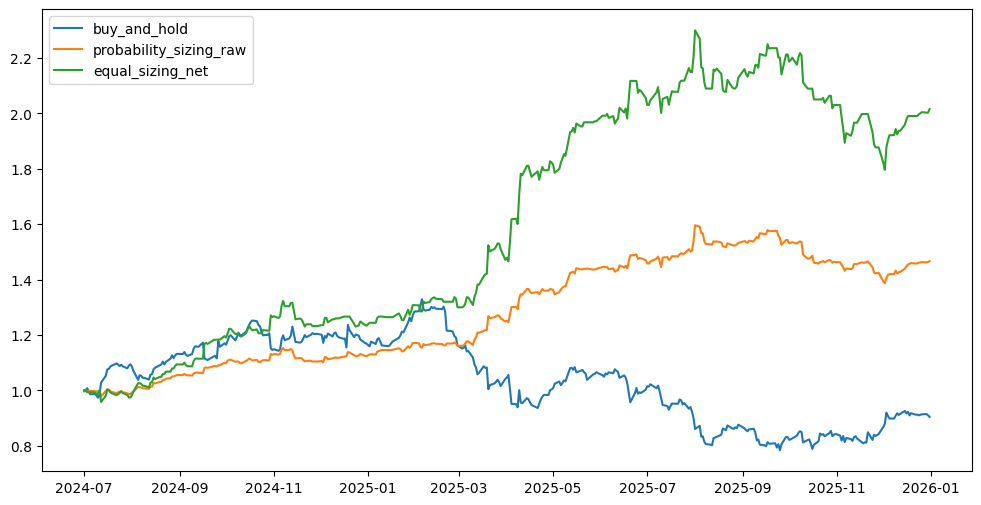

In [68]:
# PRED PROBABILITY = TRADE SIZE

test = test.copy()

test['position_size'] = 2 * test['prediction_prob'] - 1
test['position_size_shifted'] = test['position_size'].shift(1)

test['strategy_prob_ret'] = test['position_size_shifted'] * test['ret_1']
test['strategy_prob_ret'] = test['strategy_prob_ret'].fillna(0)

test['equity_prob'] = (1 + test['strategy_prob_ret']).cumprod()

plt.figure(figsize=(12,6))
plt.plot(test['buy_and_hold'], label='buy_and_hold')
plt.plot(test['equity_prob'], label='probability_sizing_raw')
plt.plot(test['equity_signal_0.6'], label='equal_sizing_net')
plt.legend()
plt.show()

In [75]:
test['prob_bucket'] = pd.cut(test['prediction_prob'], bins=[0,0.4,0.45,0.5,0.55,0.6,1.0])
test['direction'] = np.where(test['prediction_prob'] > 0.5, 1, -1)

print(test.groupby('prob_bucket')['ret_1'].mean())
print(test.groupby('direction')['ret_1'].mean())

prob_bucket
(0.0, 0.4]    -0.002077
(0.4, 0.45]   -0.000361
(0.45, 0.5]    0.001140
(0.5, 0.55]    0.001879
(0.55, 0.6]    0.000847
(0.6, 1.0]     0.000875
Name: ret_1, dtype: float64
direction
-1   -0.001460
 1    0.000982
Name: ret_1, dtype: float64


/var/folders/n8/1ntg40wj6dz8dn_j4bgmp7pc0000gn/T/ipykernel_88677/4183918825.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(test.groupby('prob_bucket')['ret_1'].mean())


For some stocks these results seems to shows that the model seems to have inverted the prediction, not following the target indicaton but having found the opposite prediction.

We try to invert the trades to confirm or decline the hypothesis.

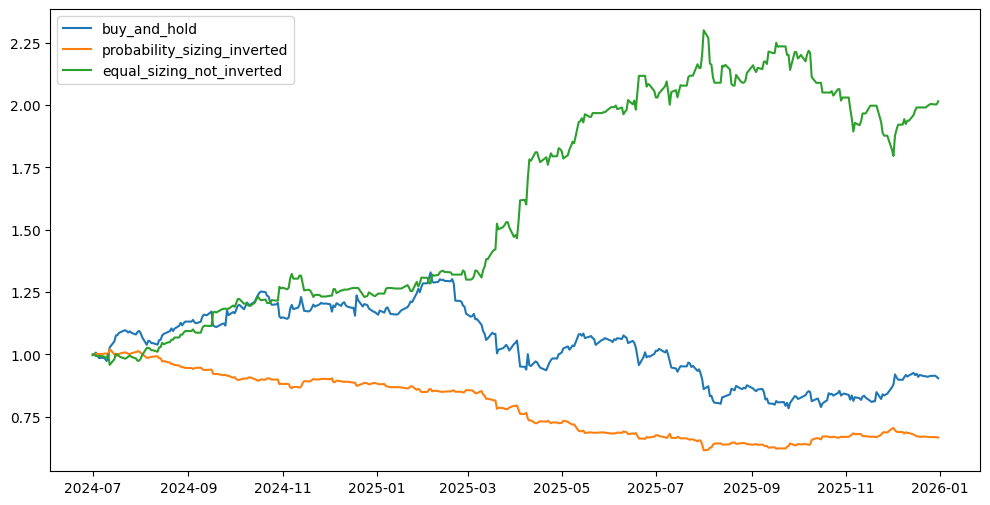

In [71]:
# PRED PROBABILITY = -(TRADE SIZE)

test = test.copy()

test['position_size'] = 2 * test['prediction_prob'] - 1
test['position_size_inv'] = -test['position_size']
test['position_size_shifted'] = test['position_size_inv'].shift(1)

test['strategy_prob_ret'] = test['position_size_shifted'] * test['ret_1']
test['strategy_prob_ret'] = test['strategy_prob_ret'].fillna(0)

test['equity_prob'] = (1 + test['strategy_prob_ret']).cumprod()

plt.figure(figsize=(12,6))
plt.plot(test['buy_and_hold'], label='buy_and_hold')
plt.plot(test['equity_prob'], label='probability_sizing_inverted')
plt.plot(test['equity_signal_0.6'], label='equal_sizing_not_inverted')
plt.legend()
plt.show()

the model is definitively rejecting the hypothesis